In [1]:
from qiskit import QuantumCircuit
from qiskit.compiler import transpile
from qiskit_aer import AerSimulator
import numpy as np
from matplotlib import pyplot as plt
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
from qiskit.quantum_info import Operator, Statevector

from tqdm import tqdm
import mthree

In [2]:
from pmns import PMNS_matrix_4x4
from hamiltonians import U1_omega_Omega, theta_ij, J_ij
from hamiltonians import nunu_interaction_p, nunu_interaction, nunu_interaction_s
from helpers import get_target_state, swap_correction_order_bp, get_interaction_pair_index, count_2q

from backend import get_sampler
from transpile import produce_transpile_args

import sys

sys.path.append('../utils/')

from JobResult import JobResult
from DecoherenceRenormalizer import DecoherenceRenormalizer as DR
from Collector import Collector

from RunSaver import RunSaver

In [3]:
run_name = '4nu_samp_m3'

rs = RunSaver(run_name)

savepath = 'results'

SAVEFLAG = True

transpile_config_path = "config/default.json"

# backend settings
# aer, sherbrooke, fez, or ibm, or marrakesh

provider = 'marrakesh'
sampler, backend, config = get_sampler(provider)
N = 4

# trotter settings
# set in natural units here
# conversion to mu^-1 happens later automatically
# dt = 5
T_max = 5.6
steps = 5

# run settings

shots = 4096

transpile_args = produce_transpile_args(config=config, path=transpile_config_path)
print(f"Transpile args: {transpile_args}")


rs.save_multiple([
    ('savepath', savepath),
    ('run_name', run_name),
    ('provider', provider),
    ('transpile_config_path', transpile_config_path),
    ('shots', shots),
    ('steps', steps),
    ('T_max', T_max),
])

Using Noisy Marrakesh simulator
Transpile args: {'optimization_level': 3, 'basis_gates': ['cz', 'id', 'delay', 'measure', 'reset', 'rz', 'sx', 'x', 'if_else', 'for_loop', 'switch_case'], 'initial_layout': None, 'approximation_degree': 1}


In [4]:
#### Defining PMNS matrix and parameters for the Hamiltonian ####
theta_12 = np.radians(33.67)
theta_13 = np.radians(8.58)
theta_23 = np.radians(42.3)
delta_CP = np.radians(232)

U_PMNS_4x4 = PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP)
assert np.allclose(U_PMNS_4x4.conj().T @ U_PMNS_4x4, np.eye(4)), "PMNS matrix is not unitary"

dm21 = 7.41e-5
dm31 = 2.505e-3
E = 1.0

delta_m21 = dm21
delta_m31 = dm31
delta_m32 = delta_m31 - delta_m21
#mu=dm31*N/(2*E) #* 1e-8
mu = dm31 * N / (2 * E)
#omega = np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3) / (4 * E)
omega=dm21 / (2 * E)  
Omega= dm31 / (2 * E)
#B3 = delta_m21 / np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3)
#B8 = (delta_m31 + delta_m32) / (np.sqrt(3) * np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3))
B3=0.025483
B8=0.999567
B = np.zeros(8)
B[2] = B3
B[7] = B8

T_max = T_max / mu
times = np.linspace(0, T_max, steps)

rs.save_multiple([
    ('dm21', dm21),
    ('dm31', dm31),
    ('E', E),
    ('mu', mu),
    ('omega', omega),
    ('Omega', Omega),
    ('B3', B3),
    ('B8', B8),
    ('B', B)
])

In [5]:
def apply_nunu_interaction(qc, pair_indices, order, base_pattern, dt, interact_func = nunu_interaction, post_fix_func = None):
    """
    interact_func: function for the interaction, for example, nunu_interaction or nunu_interaction_p
    post_fix_func: function to update the order and base_pattern after interaction, given by (order, base_pattern, i, j) -> (new_order, new_base_pattern)
    """
    for i, j in pair_indices:
        q = [2*i, 2*i+1, 2*j, 2*j+1]
        alpha_ij = J_ij(order[i], order[j], E, mu, N) * dt

        interact_func(qc, q, alpha_ij)
        order, base_pattern = post_fix_func(order, base_pattern, i, j) if post_fix_func else (order, base_pattern)
        
    return order, base_pattern


In [6]:
# initialization for run


def init_order_and_base_pattern():
    # generate initial pattern
    base_pattern = []
    for i in range(N):
        if i % 4 == 1:
            base_pattern.append('M')  # nu_mu
        elif i % 4 == 3:
            base_pattern.append('T')  # nu_tau
        else:
            base_pattern.append('E')  # nu_e

    # order map
    order = [i for i in range(N)]

    return order, base_pattern

# interaction sequence
method = "bubble"

pair_indices = get_interaction_pair_index(N, method = method)

rs.save("pair_indices", method)

collector = Collector(run_name)

rs.save("Type", "swap")
rs.log("logs")


In [ ]:
for t in times:
    collector.add("t", t * mu)

    dt = t
    print("############################################")
    print("Time step:", t)

    order, base_pattern = init_order_and_base_pattern()
    qc = QuantumCircuit(2 * N, 2 * N)

    # Initial state: alternate nu_e, nu_mu, nu_e, nu_tau pattern
    for i in range(N):
        if i % 4 == 1:
            qc.x(2*i + 1)  # nu_mu = |01⟩
        elif i % 4 == 3:
            qc.x(2*i)      # nu_tau = |10⟩

    # Apply U†_PMNS
    Udag = Operator(U_PMNS_4x4.conj().T)
    for i in range(N):
        qc.unitary(Udag, [2*i, 2*i+1], label="U†_PMNS")

    # interaction
    for i in range(N):
        qc.append(U1_omega_Omega(dt, omega, Omega), [2*i, 2*i+1])

    
    """
    Use this function for swap network
    """

    order, base_pattern = apply_nunu_interaction(qc, pair_indices, order, base_pattern, dt,
                                                    interact_func=nunu_interaction_p,
                                                    post_fix_func=swap_correction_order_bp)

    """
    Use this function for no swap (full connectivity or testing)
    """
                                                    
    # order, base_pattern = apply_nunu_interaction(qc, pair_indices, order, base_pattern, dt,
    #                                              interact_func=nunu_interaction,
    #                                              post_fix_func=None)

    # Apply U_PMNS
    # U = Operator(U_PMNS_4x4)
    for i in range(N):
        qc.unitary(Udag, [2*i, 2*i+1], label="U†_PMNS").inverse()

    # Measurement
    qc.measure(range(2 * N), reversed((range(2 * N))))

    transpile_args = produce_transpile_args(config=config, path=transpile_config_path)

    tqc = transpile(qc, backend, **transpile_args)

    print("Transpiled circuit has {0} two-qubit gates.".format(count_2q(tqc)))

    print("Initiating m3 readout error mitigation...")

    mapping = mthree.utils.final_measurement_mapping(tqc)
    
    mit = mthree.M3Mitigation(backend)

    mit.cals_from_system(mapping)

    print("M3 mitigation initialized.")

    print("Initializing DecoherenceRenormalizer...")
    dr = DR(tqc, verbose=True)
    print("Identity circuit estimate has {0} two-qubit gates.".format(count_2q(dr.get_identity_circuit())))

    dr.estimate_error_rate(service = sampler, transpile_options = transpile_args, use_m3=True, backend = backend)

    print("Estimated error rate:", dr.get_rate_estimate())
    collector.add("error_rate", dr.get_rate_estimate())

    job = JobResult(sampler, verbose=True)

    job.run(tqc, {'shots': shots})

    counts = job.get_counts()

    # Apply M3

    counts = mit.apply_correction(counts, mapping).nearest_probability_distribution()

    target_state = get_target_state(base_pattern)

    sv = Statevector.from_label(target_state)

    dr.set_trace_by_statevector(sv)

    """
    O = cI + O', Tr(O') = 0 -> c = Tr(O) / d = Tr(O) / 2^n = Tr(O) / 4^N where n = 2*N
    """

    c = dr.get_trace() / (4 ** N)

    prob = counts.get(target_state, 0)
    print("Raw probability:", prob)
    prob = dr.renormalize(prob, c = c)
    print("Renormalized probability:", prob)

    # Apply phs correction to remove 11 states
        # Perform physical correction, removing '11' states

    norm = 0

    for key in counts.keys():
        for digi in range(N):
            if key[2*digi] == '1' and key[2*digi+1] == '1':
                counts[key] = 0
                break

    for key in counts.keys():
        norm += counts[key]

    print("probability before phs:", prob)

    prob /= norm

    print("probability after phs:", prob)

    collector.add("p", prob)
    staterror = np.sqrt(prob * (1 - prob) / shots)
    collector.add("staterror", staterror)

if SAVEFLAG:
    collector.save(path=savepath)



############################################
Time step: 0.0
Transpiled circuit has 166 two-qubit gates.
Initiating m3 readout error mitigation...
M3 mitigation initialized.
Initializing DecoherenceRenormalizer...
Identity circuit estimate has 166 two-qubit gates.
Estimating error rate with 8192 shots
Job ID: dee4c910-c111-4901-bb25-b1331542ff30 submitted
Job result retrieved
Got counts for identity run.
Estimated error rate: 0.285888671875
Job ID: bc7c8daa-a26c-4a10-953b-8944ba3fd1ab submitted
Job result retrieved
Raw probability: 0.6741064
Renormalized probability: 0.9424156149839743
probability before phs: 0.9424156149839743
probability after phs: 1.0493463671245795
############################################
Time step: 279.4411177644711


/var/folders/zz/kbmmgkkj0bn_pv3w4k_0tkph0000gn/T/ipykernel_74999/1990400550.py:125: RuntimeWarning: invalid value encountered in sqrt
  staterror = np.sqrt(prob * (1 - prob) / shots)


Transpiled circuit has 235 two-qubit gates.
Initiating m3 readout error mitigation...
M3 mitigation initialized.
Initializing DecoherenceRenormalizer...
Identity circuit estimate has 235 two-qubit gates.
Estimating error rate with 8192 shots
Job ID: 5de75e10-e6e9-420e-aa92-ab606377abe4 submitted
Job result retrieved
Got counts for identity run.
Estimated error rate: 0.3829345703125
Job ID: 4a269593-fecc-4b0f-bb80-e58564a9b7c1 submitted
Job result retrieved
Raw probability: 0.49449015
Renormalized probability: 0.7989336053412462
probability before phs: 0.7989336053412462
probability after phs: 0.952331674847397
############################################
Time step: 558.8822355289421
Transpiled circuit has 234 two-qubit gates.
Initiating m3 readout error mitigation...
M3 mitigation initialized.
Initializing DecoherenceRenormalizer...
Identity circuit estimate has 234 two-qubit gates.
Estimating error rate with 8192 shots
Job ID: a50fb5af-67b9-4c6a-b2d2-7660b7a7c821 submitted
Job result 

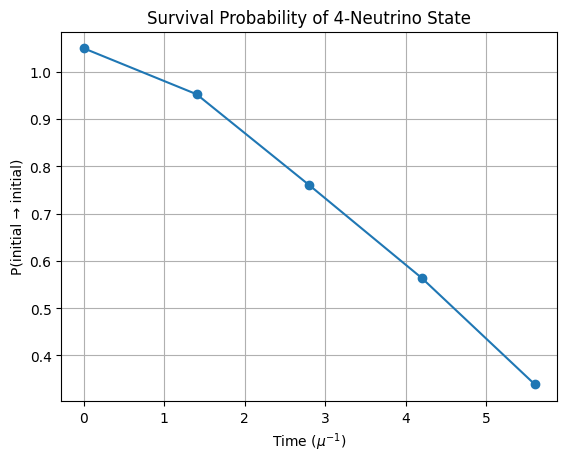

In [8]:
# Plot
plt.plot(collector.get("t"), collector.get("p"), marker='o')
plt.xlabel(r"Time ($\mu^{-1}$)")
plt.ylabel("P(initial → initial)")
plt.title("Survival Probability of {0}-Neutrino State".format(N))
plt.grid(True)
# plt.savefig(f"{run_name}_survprob.png")